Tested with following versions:



*   Python 3.11.13
*   pandas version: 2.2.2
*   matplotlib version: 3.10.0
*   scikit-learn version: 1.6.1
*   numpy version: 1.26.4
*   h2o version: 3.46.0.7

In [1]:
# Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
# Download the data
!wget -O bank-additional-full.csv https://www.dropbox.com/scl/fi/omkehbrmstg78xv1tynga/bank-additional-full.csv?rlkey=c5uuvoujyg9vzdiysv7ugin61&dl=0

# Import
rawdata = pd.read_csv("bank-additional-full.csv", sep = ";")
print(rawdata.head())
print(rawdata.shape)
print(rawdata.columns)
print(rawdata.dtypes)

--2025-07-29 21:12:18--  https://www.dropbox.com/scl/fi/omkehbrmstg78xv1tynga/bank-additional-full.csv?rlkey=c5uuvoujyg9vzdiysv7ugin61
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc186075f698b30b6238e3a13b4a.dl.dropboxusercontent.com/cd/0/inline/CuaGKfLY8Sf493ZeD3Ay5O21Cj7b5cIRhR1oCmEABzuizmb4f767_cswwEO9yZ44nqU0xVfY8KkJO3wXsYa9juRGvkBawnmL5nHjD0eQzb4XlO0kJ2OgyNeB1bn3J5OTbG7OnI985I4g5aDxm1JQBXp6/file# [following]
--2025-07-29 21:12:18--  https://uc186075f698b30b6238e3a13b4a.dl.dropboxusercontent.com/cd/0/inline/CuaGKfLY8Sf493ZeD3Ay5O21Cj7b5cIRhR1oCmEABzuizmb4f767_cswwEO9yZ44nqU0xVfY8KkJO3wXsYa9juRGvkBawnmL5nHjD0eQzb4XlO0kJ2OgyNeB1bn3J5OTbG7OnI985I4g5aDxm1JQBXp6/file
Resolving uc186075f698b30b6238e3a13b4a.dl.dropboxusercontent.com (uc186075f698b30b6238e3a13b4a.dl.dropboxusercontent.com)... 162.125.

In [3]:
pd.set_option('future.no_silent_downcasting', True)

# Recode outcome from "yes" and "no" to 1 and 0
rawdata['y'] = rawdata['y'].replace({'no': 0, 'yes': 1})

# Duration is essentially an outcome. It is unknown before the contact and y = 0 => duration = 0
# Drop duration column
rawdata = rawdata.drop(columns = ['duration'])

# Create variable indicating not previously contacted and replace 999's in pdays with 0's
rawdata['never_contacted'] = np.where(rawdata['pdays'] == 999, 1, 0)
rawdata['never_contacted'] = rawdata['never_contacted'].astype('category')
rawdata['pdays'] = np.where(rawdata['pdays'] == 999, 0, rawdata['pdays'])

In [4]:
# Split the data into training (80%) and validation (20%) sets
train, val = train_test_split(rawdata, test_size = 0.2, random_state = 94)

# For use with cross-validation later
cvsplit = KFold(n_splits = 5, shuffle = True, random_state = 94)

In [5]:
# Set data up for use with logistic regression
X_train = train.drop(columns = ['y'])
y_train = train['y']
X_val = val.drop(columns = ['y'])
y_val = val['y']

# Make sure y_train and y_val are binary type
y_train = y_train.astype(int)
y_val = y_val.astype(int)

                     0      1  accuracy    macro avg  weighted avg
precision     0.885166    0.0  0.885166     0.442583      0.783519
recall        1.000000    0.0  0.885166     0.500000      0.885166
f1-score      0.939086    0.0  0.885166     0.469543      0.831247
support    7292.000000  946.0  0.885166  8238.000000   8238.000000
Cross-entropy (Constant) = 0.3565


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


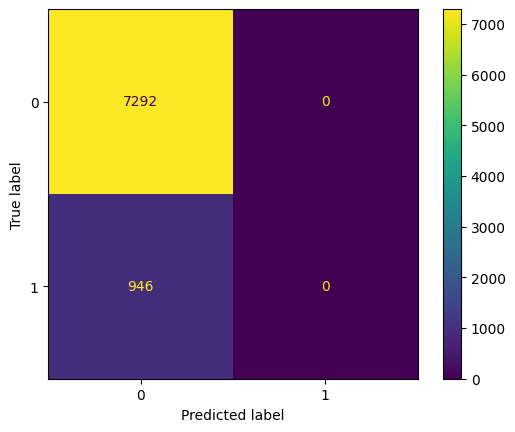

In [6]:
# Constant model - ignore features
y_pred_constant = np.zeros(len(y_val)).astype(int)
y_pred_prob_constant = np.zeros(len(y_val))+np.mean(y_train)

# Evaluate the model
constant_classification_metrics = classification_report(y_val, y_pred_constant, output_dict=True)
print(pd.DataFrame(constant_classification_metrics))

# Cross-entropy
constant_cross_entropy = -np.mean(y_val * np.log(y_pred_prob_constant) + (1 - y_val) * np.log(1 - y_pred_prob_constant))
print(f'Cross-entropy (Constant) = {constant_cross_entropy:.4f}')

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_constant)
plt.show()

                     0           1  accuracy    macro avg  weighted avg
precision     0.907716    0.699346  0.899976     0.803531      0.883788
recall        0.987383    0.226216  0.899976     0.606800      0.899976
f1-score      0.945875    0.341853  0.899976     0.643864      0.876513
support    7292.000000  946.000000  0.899976  8238.000000   8238.000000
Cross-entropy (Logistic) = 0.2803


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


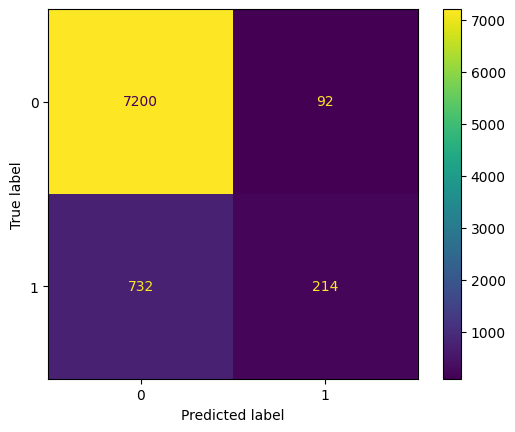

In [7]:
# Get dummy variables for our categorical features. Because we are not doing regularization or any kind of variable selection,
# we will drop one of each set of dummies.
X_train = pd.get_dummies(X_train, drop_first = True)
X_val = pd.get_dummies(X_val, drop_first = True)

# Align validation data to ensure same columns as training data
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

# Fitting the logistic regression
logistic_model = LogisticRegression(max_iter=1000, random_state=94, penalty = None)
logistic_model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_logistic = logistic_model.predict(X_val)
y_pred_prob_logistic = logistic_model.predict_proba(X_val)[:, 1]

# Evaluate the model
logistic_classification_metrics = classification_report(y_val, y_pred_logistic, output_dict=True)
print(pd.DataFrame(logistic_classification_metrics))

# Cross entropy
logistic_cross_entropy = -np.mean(y_val * np.log(y_pred_prob_logistic) + (1 - y_val) * np.log(1 - y_pred_prob_logistic))
print(f'Cross-entropy (Logistic) = {logistic_cross_entropy:.4f}')

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_logistic)
plt.show()


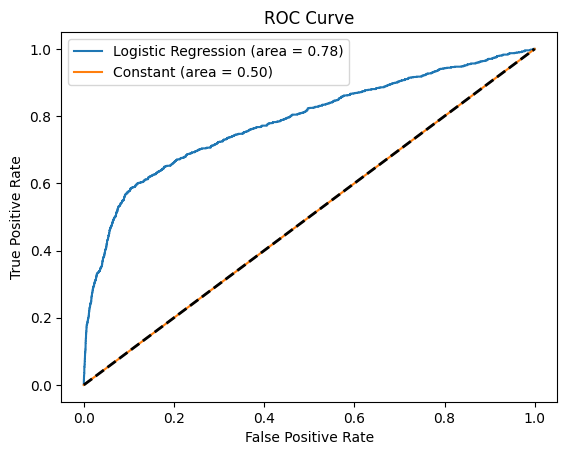

In [8]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob_logistic)
roc_auc_logistic = roc_auc_score(y_val, y_pred_prob_logistic)

fpr_con, tpr_con, thresholds_con = roc_curve(y_val, y_pred_prob_constant)
roc_auc_constant = roc_auc_score(y_val, y_pred_prob_constant)

plt.plot(fpr, tpr, label=f'Logistic Regression (area = {roc_auc_logistic:.2f})')
plt.plot(fpr_con, tpr_con, label=f'Constant (area = {roc_auc_constant:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

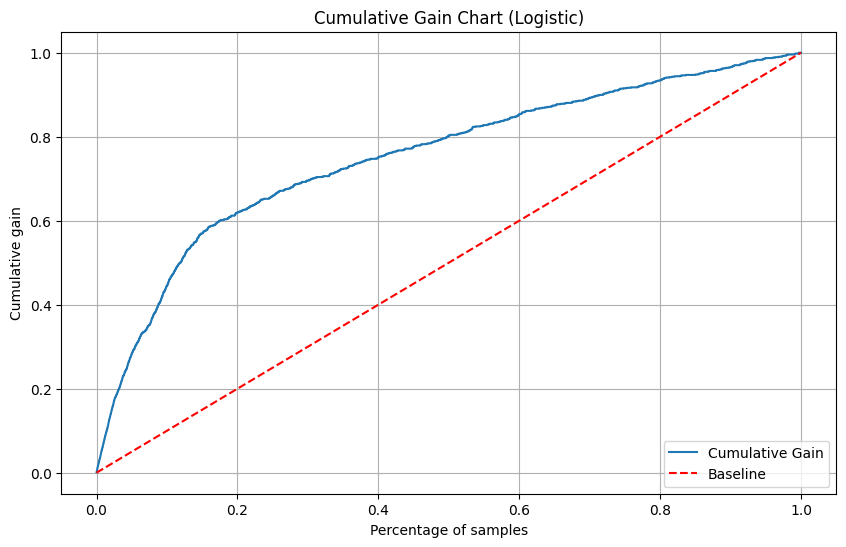

In [9]:
# Cumulative Gain
# Creating a DataFrame with the true values and predicted probabilities
data = pd.DataFrame({'true': y_val, 'prob': y_pred_prob_logistic})
data.sort_values(by='prob', ascending=False, inplace=True)

# Calculating cumulative gain
data['cumulative_gain'] = np.cumsum(data['true']) / data['true'].sum()
data['cumulative_percentage'] = np.arange(1, len(data) + 1) / len(data)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(data['cumulative_percentage'], data['cumulative_gain'], label='Cumulative Gain')
plt.plot([0, 1], [0, 1], 'r--', label='Baseline')
plt.xlabel('Percentage of samples')
plt.ylabel('Cumulative gain')
plt.title('Cumulative Gain Chart (Logistic)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

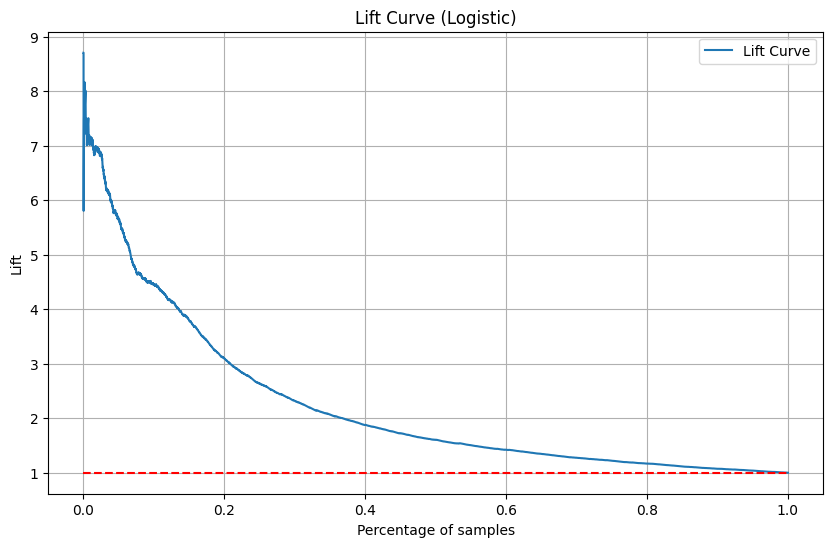

In [10]:
# Lift
# Calculating lift
data['lift'] = data['cumulative_gain'] / data['cumulative_percentage']

# Plotting lift curve
plt.figure(figsize=(10, 6))
plt.plot(data['cumulative_percentage'], data['lift'], label='Lift Curve')
plt.plot([0, 1], [1, 1], 'r--')
plt.xlabel('Percentage of samples')
plt.ylabel('Lift')
plt.title('Lift Curve (Logistic)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

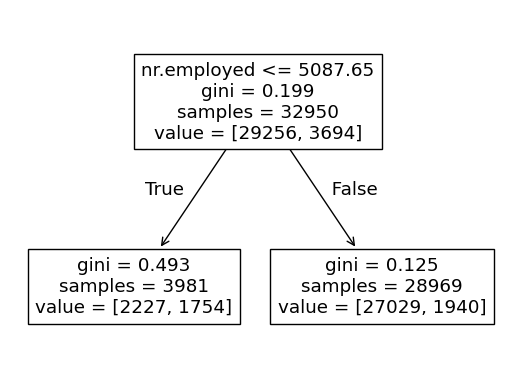

In [11]:
# Let's look at classification trees
# Start with simplest possible
tree1 = DecisionTreeClassifier(max_leaf_nodes = 2)
tree1.fit(X_train, y_train)
plot_tree(tree1, feature_names=X_train.columns)
plt.show()

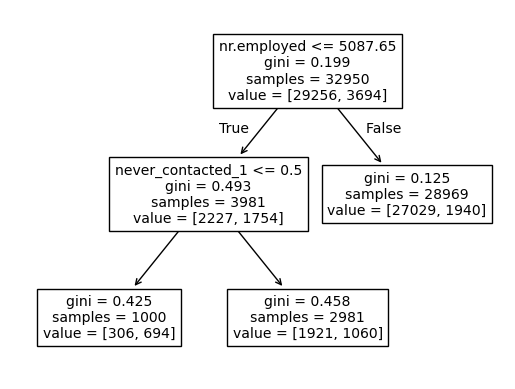

In [12]:
# Now let's look at 2 splits (3 leaves)
tree2 = DecisionTreeClassifier(max_leaf_nodes = 3)
tree2.fit(X_train, y_train)
plot_tree(tree2, feature_names=X_train.columns)
plt.show()

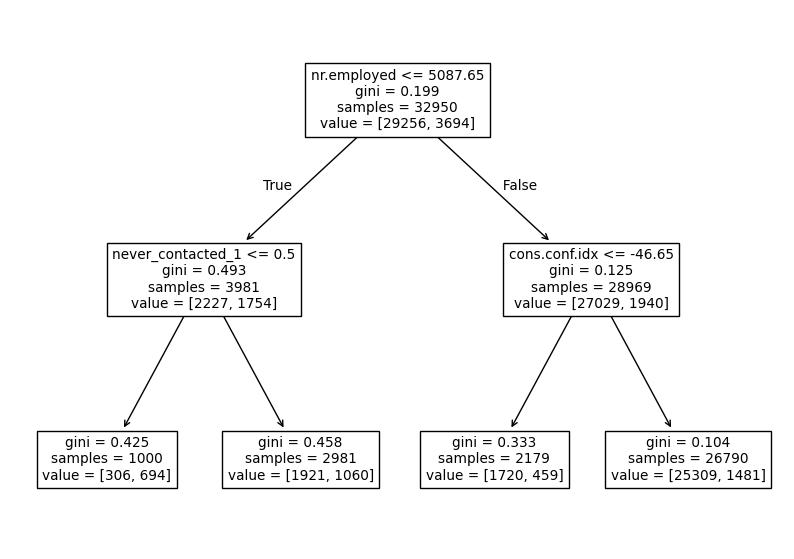

In [13]:
# Make the figure bigger than default so it's easier to read
width = 10
height = 7
plt.figure(figsize=(width, height))

# Let's fit a tree with 3 splits = 4 leaves
tree3 = DecisionTreeClassifier(max_leaf_nodes = 4)
tree3.fit(X_train, y_train)
plot_tree(tree3, feature_names=X_train.columns)
plt.show()

In [14]:
# Now let's choose the number of leaves via cross-validation using the training data

# Parameter we want to choose based on cross-validation performance - number of leaves
parameters = {'max_leaf_nodes':range(2,51)}

# Define model and do cross-validation
tree = DecisionTreeClassifier()
cv_tree = GridSearchCV(tree, parameters,
                       n_jobs=-1, scoring='neg_log_loss', refit=True, cv=cvsplit)
# We can evaluate our performance based on many different measures. We're using
# cross-entropy (aka log loss) in this example.
# The commented lines below uses accuracy or recall instead.
#cv_tree = GridSearchCV(tree, parameters, n_jobs=-1, scoring='accuracy', refit=True, cv=cvsplit)
#cv_tree = GridSearchCV(tree, parameters, n_jobs=-1, scoring='recall', refit=True, cv=cvsplit)

# Perform cross validation
cv_tree.fit(X_train, y_train)


GridSearchCV(cv=KFold(n_splits=5, random_state=94, shuffle=True),
             estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_leaf_nodes': range(2, 51)},
             scoring='neg_log_loss')

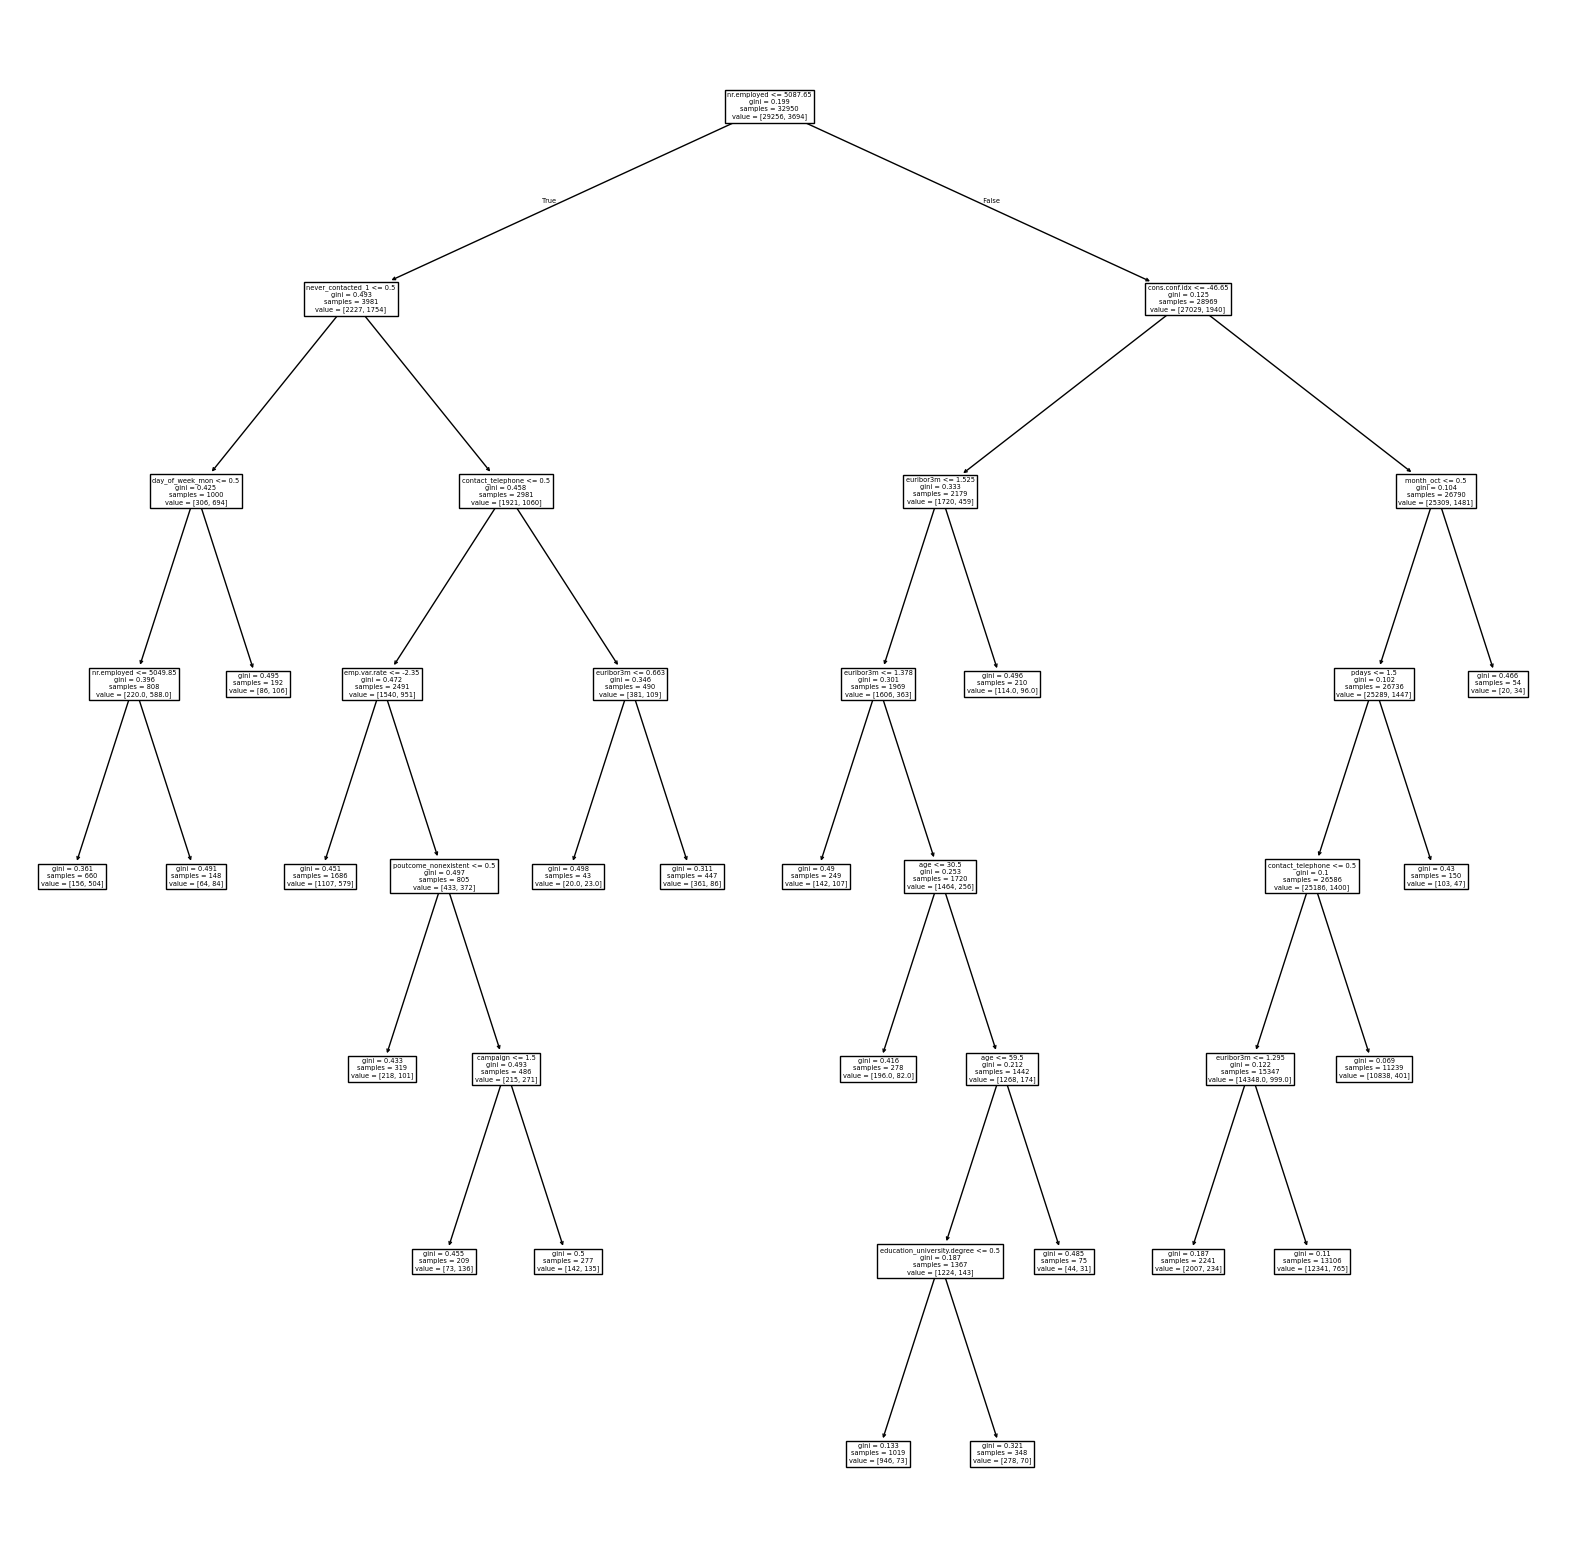

In [15]:
# Make the figure bigger than default so it's easier to read
width = 20
height = 20
plt.figure(figsize=(width, height))

# Pull out and plot the tree corresponding to the best prediction rule
# according to CV.
best_tree = cv_tree.best_estimator_

plot_tree(best_tree, feature_names = X_train.columns)
plt.show()


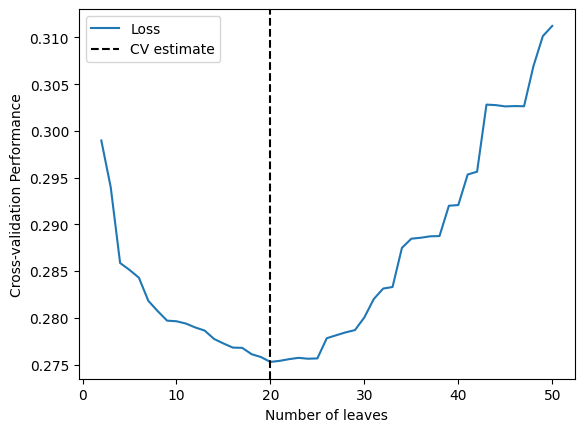

In [16]:
leaves = cv_tree.cv_results_.get('param_max_leaf_nodes')
leaves = leaves.tolist()

lranks = cv_tree.cv_results_.get('rank_test_score')
loss = -cv_tree.cv_results_.get('mean_test_score')

plt.plot(leaves, loss, label = 'Loss')
plt.axvline(cv_tree.best_params_.get('max_leaf_nodes'),
            linestyle="--", color="black", label="CV estimate")
plt.xlabel("Number of leaves")
plt.ylabel("Cross-validation Performance")
plt.legend()
plt.show()

                     0           1  accuracy    macro avg  weighted avg
precision     0.908965    0.707547   0.90119     0.808256      0.885835
recall        0.987246    0.237844   0.90119     0.612545      0.901190
f1-score      0.946490    0.356013   0.90119     0.651251      0.878683
support    7292.000000  946.000000   0.90119  8238.000000   8238.000000
Cross-entropy (Tree) = 0.2759


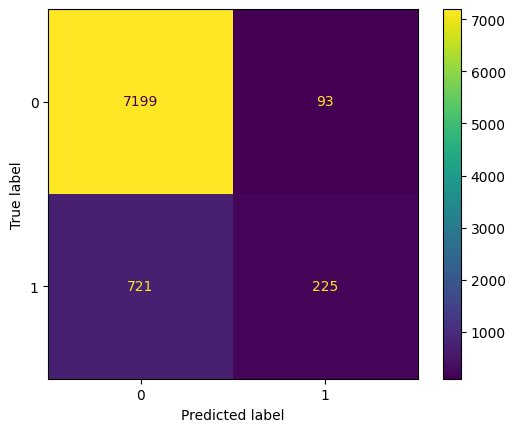

In [17]:
# Performance on the validation data
y_pred_tree = best_tree.predict(X_val)
y_pred_prob_tree = best_tree.predict_proba(X_val)[:, 1]

# Evaluate the model
tree_classification_metrics = classification_report(y_val, y_pred_tree, output_dict=True)
print(pd.DataFrame(tree_classification_metrics))

# Cross entropy
tree_cross_entropy = -np.mean(y_val * np.log(y_pred_prob_tree) + (1 - y_val) * np.log(1 - y_pred_prob_tree))
print(f'Cross-entropy (Tree) = {tree_cross_entropy:.4f}')

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_tree)
plt.show()



In [18]:
# Random forest
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 250, 500, 1000],
    'min_samples_leaf': [1, 15, 30, 60, 120]
}

# Initialize the RandomForestClassifier
rf = RandomForestClassifier(random_state=94)

# Cross validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cvsplit, scoring='neg_log_loss', n_jobs=-1)
grid_search.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=KFold(n_splits=5, random_state=94, shuffle=True),
             estimator=RandomForestClassifier(random_state=94), n_jobs=-1,
             param_grid={'min_samples_leaf': [1, 15, 30, 60, 120],
                         'n_estimators': [100, 250, 500, 1000]},
             scoring='neg_log_loss')

In [19]:
# Create dataframe with cv metrics
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['mean_test_score'] = -cv_results['mean_test_score']
print(cv_results[['param_min_samples_leaf', 'param_n_estimators', 'mean_test_score']])

    param_min_samples_leaf  param_n_estimators  mean_test_score
0                        1                 100         0.496343
1                        1                 250         0.385055
2                        1                 500         0.331215
3                        1                1000         0.314575
4                       15                 100         0.272150
5                       15                 250         0.271963
6                       15                 500         0.271842
7                       15                1000         0.271781
8                       30                 100         0.272634
9                       30                 250         0.272589
10                      30                 500         0.272623
11                      30                1000         0.272596
12                      60                 100         0.274422
13                      60                 250         0.274324
14                      60              

                     0           1  accuracy    macro avg  weighted avg
precision     0.907293    0.702341  0.899854     0.804817      0.883758
recall        0.987795    0.221987  0.899854     0.604891      0.899854
f1-score      0.945834    0.337349  0.899854     0.641592      0.875960
support    7292.000000  946.000000  0.899854  8238.000000   8238.000000
Cross-entropy (RF) = 0.2737


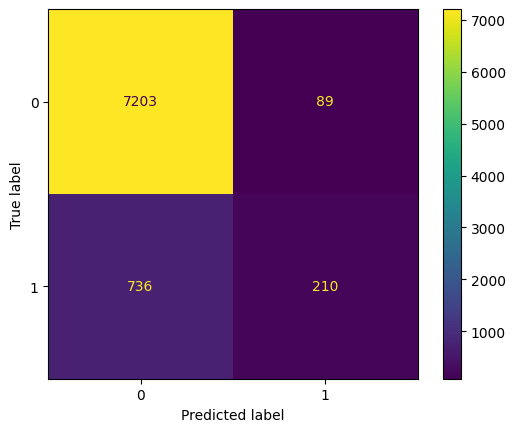

In [20]:
# Get best model (based on cv)
best_rf = grid_search.best_estimator_

# Performance on the validation data
y_pred_rf = best_rf.predict(X_val)
y_pred_prob_rf = best_rf.predict_proba(X_val)[:, 1]

# Evaluate the model
rf_classification_metrics = classification_report(y_val, y_pred_rf, output_dict=True)
print(pd.DataFrame(rf_classification_metrics))

# Cross-entropy
rf_cross_entropy = -np.mean(y_val * np.log(y_pred_prob_rf) + (1 - y_val) * np.log(1 - y_pred_prob_rf))
print(f'Cross-entropy (RF) = {rf_cross_entropy:.4f}')

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf)
plt.show()

In [21]:
# Let's try with boosting
# Define the parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 1],
    'max_depth': [2, 3, 4, 5, 6],
    'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}

# Initialize the GradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state=94)

grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid, cv=cvsplit, scoring='neg_log_loss', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=94, shuffle=True),
             estimator=GradientBoostingClassifier(random_state=94), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 1],
                         'max_depth': [2, 3, 4, 5, 6],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             scoring='neg_log_loss')

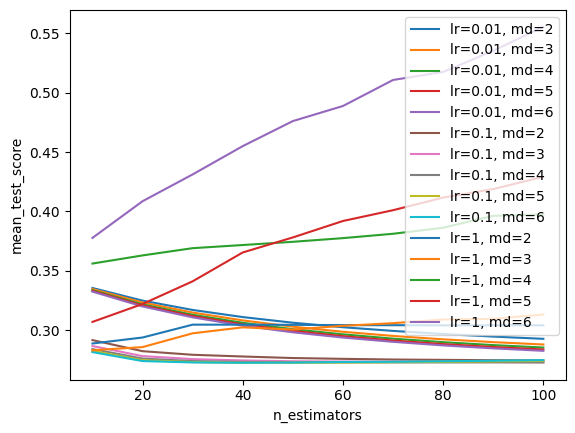

In [22]:
# Create dataframe with cv metrics
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['mean_test_score'] = -cv_results['mean_test_score']

# Plot cv results with separate lines for each learning rate/depth combination
plt.figure
for learning_rate in param_grid['learning_rate']:
    for max_depth in param_grid['max_depth']:
        mask = (cv_results['param_learning_rate'] == learning_rate) & (cv_results['param_max_depth'] == max_depth)
        plt.plot(cv_results[mask]['param_n_estimators'], cv_results[mask]['mean_test_score'], label=f'lr={learning_rate}, md={max_depth}')

plt.legend()
plt.xlabel('n_estimators')
plt.ylabel('mean_test_score')
plt.show()

Cross-entropy (GBC) = 0.2750
                     0           1  accuracy    macro avg  weighted avg
precision     0.909691    0.643836  0.897912     0.776763      0.879162
recall        0.982172    0.248414  0.897912     0.615293      0.897912
f1-score      0.944543    0.358505  0.897912     0.651524      0.877246
support    7292.000000  946.000000  0.897912  8238.000000   8238.000000


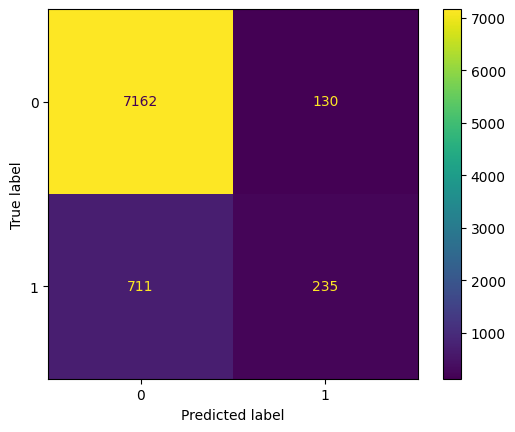

In [23]:
# Get best model based on cv
best_gbc = grid_search.best_estimator_

# Performance on validation data
y_pred_gbc = best_gbc.predict(X_val)
y_pred_prob_gbc = best_gbc.predict_proba(X_val)[:, 1]

# Cross entropy
gbc_cross_entropy = -np.mean(y_val * np.log(y_pred_prob_gbc) + (1 - y_val) * np.log(1 - y_pred_prob_gbc))
print(f'Cross-entropy (GBC) = {gbc_cross_entropy:.4f}')

# Evaluate the model
gbc_classification_metrics = classification_report(y_val, y_pred_gbc, output_dict=True)
print(pd.DataFrame(gbc_classification_metrics))

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_gbc)
plt.show()

Best model parameters: learning_rate=0.1, max_depth=6
                     0           1  accuracy    macro avg  weighted avg
precision     0.910766    0.657682  0.899369     0.784224      0.881704
recall        0.982584    0.257928  0.899369     0.620256      0.899369
f1-score      0.945313    0.370539  0.899369     0.657926      0.879310
support    7292.000000  946.000000  0.899369  8238.000000   8238.000000
Cross-entropy (GBCES) = 0.2750


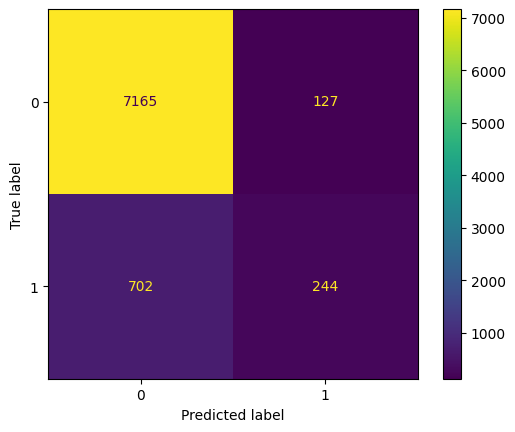

In [24]:
# Redo GBC using early stopping
# Define the parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 1],
    'max_depth': [2, 3, 4, 5, 6]
}

# Early stopping criteria
best_model = None
best_score = float('inf')

for learning_rate in param_grid['learning_rate']:
    for max_depth in param_grid['max_depth']:
        # Initialize the GradientBoostingClassifier with early stopping
        gbcES = GradientBoostingClassifier(
            learning_rate=learning_rate,
            max_depth=max_depth,
            n_estimators=200,
            validation_fraction=0.2,
            n_iter_no_change=10,
            tol=1e-4,
            random_state=94
        )

        # Fit the model
        gbcES.fit(X_train, y_train)

        # Evaluate the validation loss from the internal validation split
        val_loss = min(gbcES.train_score_[-10:])  # Use the lowest validation loss from early stopping

        if val_loss < best_score:
            best_score = val_loss
            best_model = gbcES

# Print the best parameters
print(f"Best model parameters: learning_rate={best_model.learning_rate}, max_depth={best_model.max_depth}")

# Evaluate the best model on the test data
y_pred_gbcES = best_model.predict(X_val)
y_pred_prob_gbcES = best_model.predict_proba(X_val)[:, 1]

# Evaluate the model
gbcES_classification_metrics = classification_report(y_val, y_pred_gbcES, output_dict=True)
print(pd.DataFrame(gbcES_classification_metrics))

# Cross entropy
gbcES_cross_entropy = -np.mean(y_val * np.log(y_pred_prob_gbcES) + (1 - y_val) * np.log(1 - y_pred_prob_gbcES))
print(f'Cross-entropy (GBCES) = {gbcES_cross_entropy:.4f}')

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_gbcES)
plt.show()


Text(0.5, 1.0, 'Validation Accuracy')

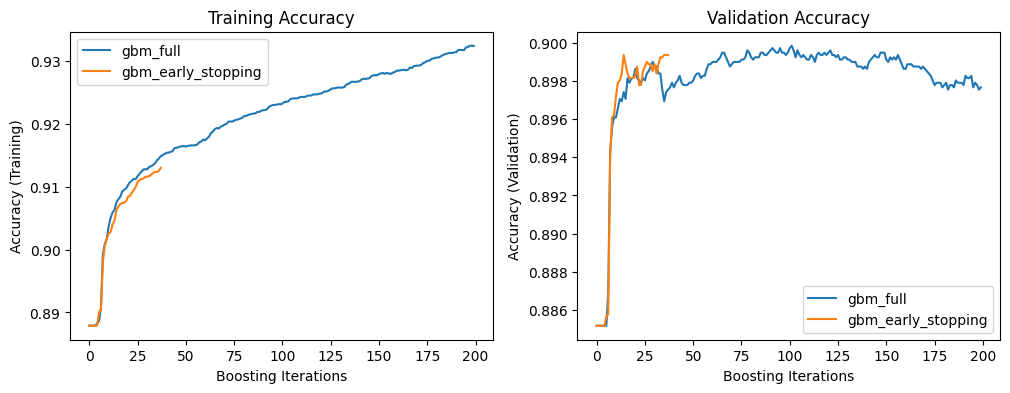

In [25]:
# Retrain using the best parameters without early stopping
long_model = GradientBoostingClassifier(
    learning_rate=best_gbc.learning_rate,
    max_depth=best_gbc.max_depth,
    n_estimators=200,
    random_state=94
)
long_model.fit(X_train, y_train)


train_acc_without = []
val_acc_without = []

train_acc_with = []
val_acc_with = []

for i, (train_pred, val_pred) in enumerate(
    zip(
        long_model.staged_predict(X_train),
        long_model.staged_predict(X_val),
    )
):
    train_acc_without.append(accuracy_score(y_train, train_pred))
    val_acc_without.append(accuracy_score(y_val, val_pred))

for i, (train_pred, val_pred) in enumerate(
    zip(
        best_model.staged_predict(X_train),
        best_model.staged_predict(X_val),
    )
):
    train_acc_with.append(accuracy_score(y_train, train_pred))
    val_acc_with.append(accuracy_score(y_val, val_pred))



fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

axes[0].plot(train_acc_without, label="gbm_full")
axes[0].plot(train_acc_with, label="gbm_early_stopping")
axes[0].set_xlabel("Boosting Iterations")
axes[0].set_ylabel("Accuracy (Training)")
axes[0].legend()
axes[0].set_title("Training Accuracy")

axes[1].plot(val_acc_without, label="gbm_full")
axes[1].plot(val_acc_with, label="gbm_early_stopping")
axes[1].set_xlabel("Boosting Iterations")
axes[1].set_ylabel("Accuracy (Validation)")
axes[1].legend()
axes[1].set_title("Validation Accuracy")

In [26]:
# Evaluate on the basis of an "economic" metric
#For simplicity, let's suppose that there is a cost  C=100  of contacting an individual.
#
#Let's suppose that a customer who is contacted and opens an account has the following characteristics:
#
#Initial deposit = 1000, average maintained balance = 2000
#Assessed fees = 50/year
#Takes out credit card that generates 100 in fees and interest/year
#Stays with the bank for 5 years
#
#Let's further assume that the bank
#
#gets 5%/year in interest from loans made from deposits
#incurs costs of 100 initially and 20/year for account maintenance, setup, ...
#has a discount rate of 5%
#
#From this, we have that the net revenue of the customer is (100+50+100-100-20 = 130) in year 1
#and (100+50+100-20 = 230) in years 2-5.
#Lifetime value of the customer is then approximately  R=(130)/(1.05)+sum(j=2,..,5)(230)(1.05^j)=904~900.
#
# Expected benefit - assuming we get TP and FP exactly as in our predictions -
# P(TP)*(R-C)+P(FP)*(-C)

# Assume "contacting" anyone with predicted take-up > .5
# Confusion matrix for constant model
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_constant).ravel()
# Confusion matrix for logistic model
tn_log, fp_log, fn_log, tp_log = confusion_matrix(y_val, y_pred_logistic).ravel()
# Confusion matrix for tree model
tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(y_val, y_pred_tree).ravel()
# Confusion matrix for random forest model
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_val, y_pred_rf).ravel()
# Confusion matrix for boosting model
tn_gbc, fp_gbc, fn_gbc, tp_gbc = confusion_matrix(y_val, y_pred_gbc).ravel()
# Confusion matrix for boosting model (early stopping)
tn_gbcES, fp_gbcES, fn_gbcES, tp_gbcES = confusion_matrix(y_val, y_pred_gbcES).ravel()

# Hypothetical value of customer opening deposit
R = 900
# Hypothetical "benefit" of contacting customer
C = -100

# Expected profit from constant model
N = tn+fp+fn+tp  # Total number of observations
Epi_con = (tp/N)*(R+C)+(fp/N)*C
# Expected profit from logistic model
Epi_log = (tp_log/N)*(R+C)+(fp_log/N)*C
# Expected profit from tree model
Epi_tr = (tp_tr/N)*(R+C)+(fp_tr/N)*C
# Expected profit from random forest model
Epi_rf = (tp_rf/N)*(R+C)+(fp_rf/N)*C
# Expected profit from boosting model
Epi_gbc = (tp_gbc/N)*(R+C)+(fp_gbc/N)*C
# Expected profit from boosting model (early stopping)
Epi_gbcES = (tp_gbcES/N)*(R+C)+(fp_gbcES/N)*C


print(f"Expected profit from constant model: {Epi_con}")
print(f"Expected profit from logistic model: {Epi_log}")
print(f"Expected profit from tree model: {Epi_tr}")
print(f"Expected profit from random forest model: {Epi_rf}")
print(f"Expected profit from boosted tree model: {Epi_gbc}")
print(f"Expected profit from boosted tree model (early stopping): {Epi_gbcES}")


Expected profit from constant model: 0.0
Expected profit from logistic model: 19.664967225054625
Expected profit from tree model: 20.721048798252003
Expected profit from random forest model: 19.31294003398883
Expected profit from boosted tree model: 21.24302015052197
Expected profit from boosted tree model (early stopping): 22.153435299830054


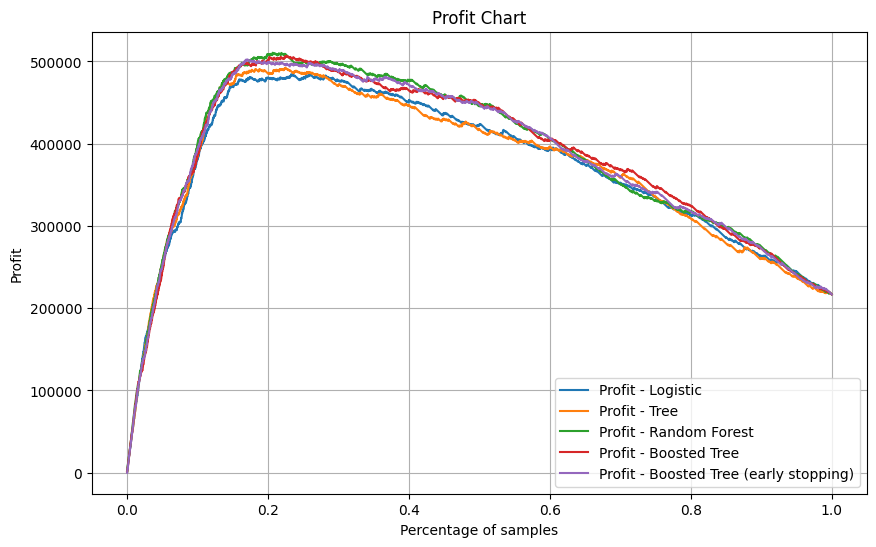

Predicted takeup probability threshold (logistic): 0.10317879837190823
Maximum profit (logistic): 484500
Accuracy (logistic): 0.8014081087642632
Predicted takeup probability threshold (tree): 0.10441767068273092
Maximum profit (tree): 490300
Accuracy (tree): 0.8082058752124301
Predicted takeup probability threshold (random forest): 0.10872007393612117
Maximum profit (random forest): 510600
Accuracy (random forest): 0.8287205632435057
Predicted takeup probability threshold (boosted trees): 0.10546459698383685
Maximum profit (boosted trees): 508300
Accuracy (boosted trees): 0.8312697256615683
Predicted takeup probability threshold (boosted trees, early): 0.17448403489620137
Maximum profit (boosted trees, early): 494100
Accuracy (boosted trees, early): 0.8739985433357611


In [27]:
# Consider choosing threshold for contact based on
# 1. First, order all individuals in the sample according to predicted probability of take-up.
# 2. Consider varying the threshold for contact (or alternatively the fraction of the sample to contact) between 1 (contact no one) and 0 (contact everyone)
# 3. Choose the model and threshold that gives the highest "profit." (All the true ones give a benefit of R-C, and all the true zeros give a benefit of -C.)
# Creating a DataFrame with the true values and predicted probabilities
datalog = pd.DataFrame({'true': y_val, 'prob': y_pred_prob_logistic})
datalog.sort_values(by='prob', ascending=False, inplace=True)

datatr = pd.DataFrame({'true': y_val, 'prob': y_pred_prob_tree})
datatr.sort_values(by='prob', ascending=False, inplace=True)

datarf = pd.DataFrame({'true': y_val, 'prob': y_pred_prob_rf})
datarf.sort_values(by='prob', ascending=False, inplace=True)

datagbc = pd.DataFrame({'true': y_val, 'prob': y_pred_prob_gbc})
datagbc.sort_values(by='prob', ascending=False, inplace=True)

datagbcES = pd.DataFrame({'true': y_val, 'prob': y_pred_prob_gbcES})
datagbcES.sort_values(by='prob', ascending=False, inplace=True)

# Calculate "profit" from contacting people ordered by their predicted probability
datalog['profit'] = np.cumsum(datalog['true']*(R-C)+(1-datalog['true'])*C)
datalog['cumulative_percentage'] = np.arange(1, len(datalog) + 1) / len(datalog)

datatr['profit'] = np.cumsum(datatr['true']*(R-C)+(1-datatr['true'])*C)
datatr['cumulative_percentage'] = np.arange(1, len(datatr) + 1) / len(datatr)

datarf['profit'] = np.cumsum(datarf['true']*(R-C)+(1-datarf['true'])*C)
datarf['cumulative_percentage'] = np.arange(1, len(datarf) + 1) / len(datarf)

datagbc['profit'] = np.cumsum(datagbc['true']*(R-C)+(1-datagbc['true'])*C)
datagbc['cumulative_percentage'] = np.arange(1, len(datagbc) + 1) / len(datagbc)

datagbcES['profit'] = np.cumsum(datagbcES['true']*(R-C)+(1-datagbcES['true'])*C)
datagbcES['cumulative_percentage'] = np.arange(1, len(datagbcES) + 1) / len(datagbcES)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(datalog['cumulative_percentage'], datalog['profit'], label='Profit - Logistic')
plt.plot(datarf['cumulative_percentage'], datatr['profit'],
         label='Profit - Tree')
plt.plot(datarf['cumulative_percentage'], datarf['profit'],
         label='Profit - Random Forest')
plt.plot(datagbc['cumulative_percentage'], datagbc['profit'],
         label='Profit - Boosted Tree')
plt.plot(datagbcES['cumulative_percentage'], datagbcES['profit'],
         label='Profit - Boosted Tree (early stopping)')
plt.xlabel('Percentage of samples')
plt.ylabel('Profit')
plt.title('Profit Chart')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Get predicted probability in row corresponding to maximum profit (logistic)
logprob = datalog.loc[datalog['profit'].idxmax(),'prob']
print(f"Predicted takeup probability threshold (logistic): {logprob}")
logprof = datalog.loc[datalog['profit'].idxmax(),'profit']
print(f"Maximum profit (logistic): {logprof}")

# Let's calculate accuracy using this decision threshold
logpredictions = (y_pred_prob_logistic >= logprob).astype(int)
logaccuracy = np.mean(logpredictions == y_val)
print(f"Accuracy (logistic): {logaccuracy}")

# Get predicted probability in row corresponding to maximum profit (tree)
treeprob = datatr.loc[datatr['profit'].idxmax(),'prob']
print(f"Predicted takeup probability threshold (tree): {treeprob}")
treeprof = datatr.loc[datalog['profit'].idxmax(),'profit']
print(f"Maximum profit (tree): {treeprof}")

# Let's calculate accuracy using this decision threshold
treepredictions = (y_pred_prob_tree >= treeprob).astype(int)
treeaccuracy = np.mean(treepredictions == y_val)
print(f"Accuracy (tree): {treeaccuracy}")

# Get predicted probability in row corresponding to maximum profit (random forest)
rfprob = datarf.loc[datarf['profit'].idxmax(),'prob']
print(f"Predicted takeup probability threshold (random forest): {rfprob}")
rfprof = datarf.loc[datarf['profit'].idxmax(),'profit']
print(f"Maximum profit (random forest): {rfprof}")

# Let's calculate accuracy using this decision threshold
rfpredictions = (y_pred_prob_rf >= rfprob).astype(int)
rfaccuracy = np.mean(rfpredictions == y_val)
print(f"Accuracy (random forest): {rfaccuracy}")

# Get predicted probability in row corresponding to maximum profit (boosted trees)
gbcprob = datarf.loc[datagbc['profit'].idxmax(),'prob']
print(f"Predicted takeup probability threshold (boosted trees): {gbcprob}")
gbcprof = datarf.loc[datagbc['profit'].idxmax(),'profit']
print(f"Maximum profit (boosted trees): {gbcprof}")

# Let's calculate accuracy using this decision threshold
gbcpredictions = (y_pred_prob_gbc >= gbcprob).astype(int)
gbcaccuracy = np.mean(gbcpredictions == y_val)
print(f"Accuracy (boosted trees): {gbcaccuracy}")

# Get predicted probability in row corresponding to maximum profit (boosted trees, early)
gbcESprob = datarf.loc[datagbcES['profit'].idxmax(),'prob']
print(f"Predicted takeup probability threshold (boosted trees, early): {gbcESprob}")
gbcESprof = datarf.loc[datagbcES['profit'].idxmax(),'profit']
print(f"Maximum profit (boosted trees, early): {gbcESprof}")

# Let's calculate accuracy using this decision threshold
gbcESpredictions = (y_pred_prob_gbcES >= gbcESprob).astype(int)
gbcESaccuracy = np.mean(gbcESpredictions == y_val)
print(f"Accuracy (boosted trees, early): {gbcESaccuracy}")



[0.04058929 0.09414333 0.55708155 0.34168417]
-0.003807527414081441
                     0           1  accuracy    macro avg  weighted avg
precision     0.909056    0.664723  0.898883     0.786890      0.880999
recall        0.984229    0.241015  0.898883     0.612622      0.898883
f1-score      0.945150    0.353763  0.898883     0.649457      0.877239
support    7292.000000  946.000000  0.898883  8238.000000   8238.000000
Cross-entropy (stack) = 0.2726


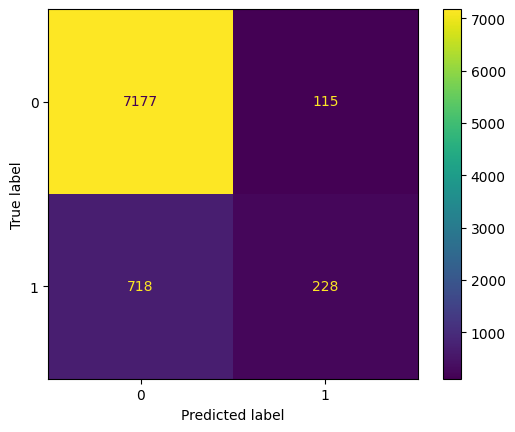

Expected profit from stacked model: 20.745326535566882


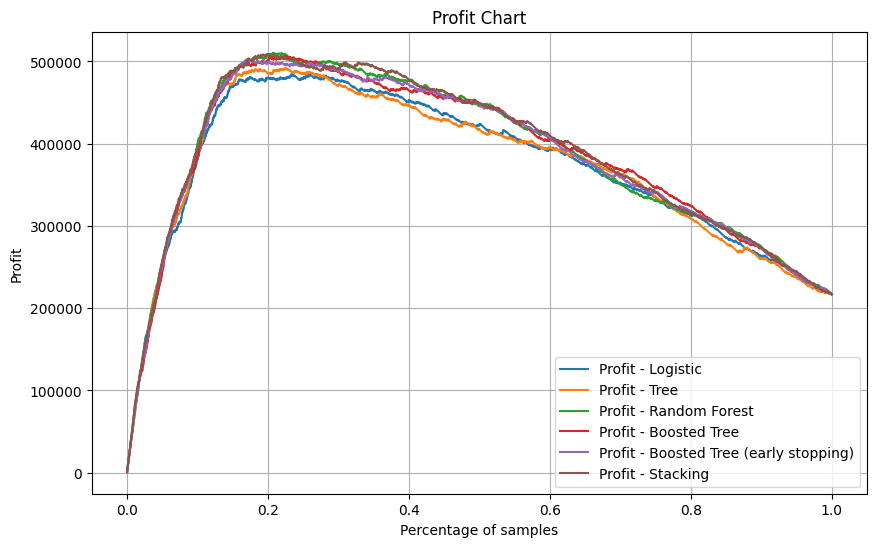

Predicted takeup probability threshold (stacking): 0.10987690664813546
Maximum profit (stacking): 508900
Accuracy (stacking): 0.8353969410050983


In [28]:
# Stacking
# We are going to drop early stopping and stack based on cross-validated
# predicted values within the training data. We would need to do early
# stopping within cross-validation if we wanted to use it here.

cv_log = cross_val_predict(logistic_model, X_train, y_train,
                           cv=cvsplit, method='predict_proba', n_jobs = -1)
cv_tree = cross_val_predict(best_tree, X_train, y_train,
                            cv=cvsplit, method='predict_proba', n_jobs = -1)
cv_rf = cross_val_predict(best_rf, X_train, y_train,
                          cv=cvsplit, method='predict_proba', n_jobs = -1)
cv_gbc = cross_val_predict(best_gbc, X_train, y_train,
                           cv=cvsplit, method='predict_proba', n_jobs = -1)

# Linear regression of y_train on the cross-validated predictions
stack_model = LinearRegression()
stack_model.fit(np.column_stack((cv_log[:, 1], cv_tree[:, 1], cv_rf[:, 1], cv_gbc[:, 1])), y_train)

# Coefficients from fitted linear model
print(stack_model.coef_)
print(stack_model.intercept_)

# Use fitted model to obtain predicted values in validation data
y_pred_stack_prob = stack_model.predict(np.column_stack((y_pred_prob_logistic, y_pred_prob_tree, y_pred_prob_rf, y_pred_prob_gbc)))
y_pred_stack = (y_pred_stack_prob >= 0.5).astype(int)

# Evaluate stacking model
stack_classification_metrics = classification_report(y_val, y_pred_stack, output_dict=True)
print(pd.DataFrame(stack_classification_metrics))

# cross entropy
stack_cross_entropy = -np.mean(y_val * np.log(y_pred_stack_prob) + (1 - y_val) * np.log(1 - y_pred_stack_prob))
print(f'Cross-entropy (stack) = {stack_cross_entropy:.4f}')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_stack)
plt.show()

# Profit
# Confusion matrix for stacked model
tn_stack, fp_stack, fn_stack, tp_stack = confusion_matrix(y_val, y_pred_stack).ravel()

# Expected profit from stacked model
Epi_stack = (tp_stack/N)*(R+C)+(fp_stack/N)*C
print(f"Expected profit from stacked model: {Epi_stack}")

# Add stacked model to profit figure
# Creating a DataFrame with the true values and predicted probabilities
datastack = pd.DataFrame({'true': y_val, 'prob': y_pred_stack_prob})
datastack.sort_values(by='prob', ascending=False, inplace=True)

# Calculate "profit" from contacting people ordered by their predicted probability
datastack['profit'] = np.cumsum(datastack['true']*(R-C)+(1-datastack['true'])*C)
datastack['cumulative_percentage'] = np.arange(1, len(datastack) + 1) / len(datastack)

# Figure
plt.figure(figsize=(10, 6))
plt.plot(datalog['cumulative_percentage'], datalog['profit'], label='Profit - Logistic')
plt.plot(datarf['cumulative_percentage'], datatr['profit'],
         label='Profit - Tree')
plt.plot(datarf['cumulative_percentage'], datarf['profit'],
         label='Profit - Random Forest')
plt.plot(datagbc['cumulative_percentage'], datagbc['profit'],
         label='Profit - Boosted Tree')
plt.plot(datagbcES['cumulative_percentage'], datagbcES['profit'],
         label='Profit - Boosted Tree (early stopping)')
plt.plot(datastack['cumulative_percentage'], datastack['profit'],
         label='Profit - Stacking')
plt.xlabel('Percentage of samples')
plt.ylabel('Profit')
plt.title('Profit Chart')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Get predicted probability in row corresponding to maximum profit (stacking)
stackprob = datastack.loc[datastack['profit'].idxmax(),'prob']
print(f"Predicted takeup probability threshold (stacking): {stackprob}")
stackprof = datastack.loc[datastack['profit'].idxmax(),'profit']
print(f"Maximum profit (stacking): {stackprof}")

# Let's calculate accuracy using this decision threshold
stackpredictions = (y_pred_stack_prob >= stackprob).astype(int)
stackaccuracy = np.mean(stackpredictions == y_val)
print(f"Accuracy (stacking): {stackaccuracy}")


[0.04058929 0.09414333 0.55708155 0.34168417]
-0.003807527414081441
                     0           1  accuracy    macro avg  weighted avg
precision     0.909056    0.664723  0.898883     0.786890      0.880999
recall        0.984229    0.241015  0.898883     0.612622      0.898883
f1-score      0.945150    0.353763  0.898883     0.649457      0.877239
support    7292.000000  946.000000  0.898883  8238.000000   8238.000000
Cross-entropy (val_stack) = 0.2726


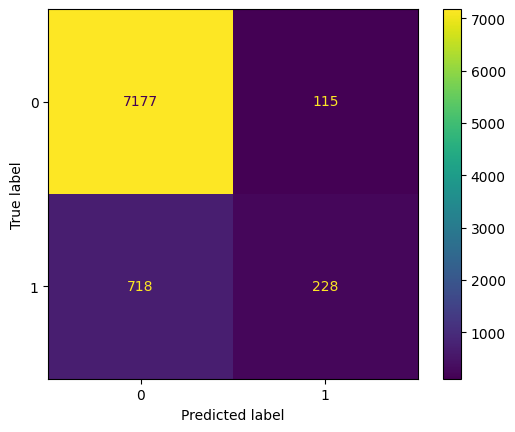

Expected profit from val_stacked model: 20.745326535566882


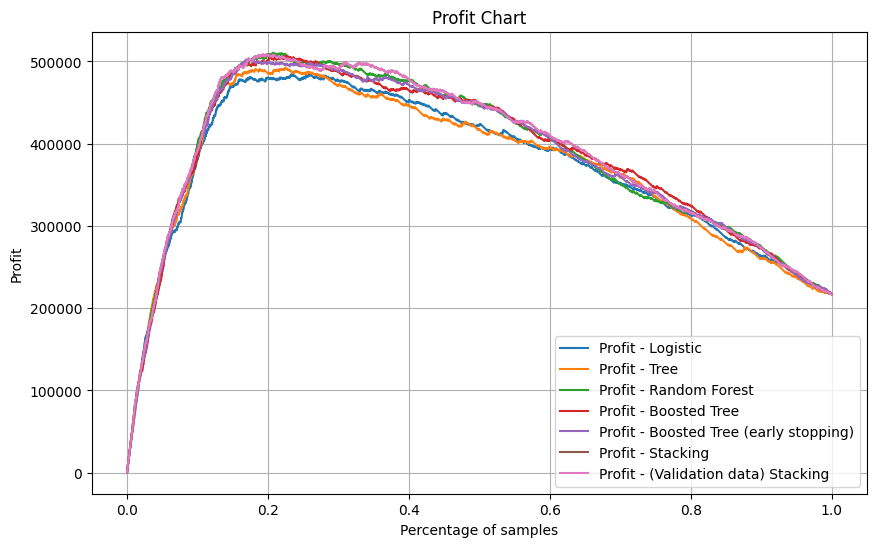

Predicted takeup probability threshold (val_stacking): 0.10987690664813546
Maximum profit (val_stacking): 508900
Accuracy (val_stacking): 0.8353969410050983


In [29]:
# For comparison, we are going to look at stacking using the validation data
# predicted values and all learners. We would ideally have a further testing
# sample set aside if we were using this approach though.

# Linear regression of y_val on the validation data predictions
val_stack_model = LinearRegression()
val_stack_model.fit(np.column_stack((cv_log[:, 1], cv_tree[:, 1], cv_rf[:, 1], cv_gbc[:, 1])), y_train)

# Coefficients from fitted linear model
print(val_stack_model.coef_)
print(val_stack_model.intercept_)

# Use fitted model to obtain predicted values in validation data
y_pred_val_stack_prob = val_stack_model.predict(np.column_stack((y_pred_prob_logistic, y_pred_prob_tree, y_pred_prob_rf, y_pred_prob_gbc)))
y_pred_val_stack = (y_pred_val_stack_prob >= 0.5).astype(int)

# Evaluate stacking model
val_stack_classification_metrics = classification_report(y_val, y_pred_val_stack, output_dict=True)
print(pd.DataFrame(val_stack_classification_metrics))

# cross entropy
val_stack_cross_entropy = -np.mean(y_val * np.log(y_pred_val_stack_prob) + (1 - y_val) * np.log(1 - y_pred_val_stack_prob))
print(f'Cross-entropy (val_stack) = {val_stack_cross_entropy:.4f}')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_stack)
plt.show()

# Profit
# Confusion matrix for stacked model
tn_val_stack, fp_val_stack, fn_val_stack, tp_val_stack = confusion_matrix(y_val, y_pred_val_stack).ravel()

# Expected profit from stacked model
Epi_val_stack = (tp_val_stack/N)*(R+C)+(fp_val_stack/N)*C
print(f"Expected profit from val_stacked model: {Epi_val_stack}")

# Add stacked model to profit figure
# Creating a DataFrame with the true values and predicted probabilities
dataval_stack = pd.DataFrame({'true': y_val, 'prob': y_pred_val_stack_prob})
dataval_stack.sort_values(by='prob', ascending=False, inplace=True)

# Calculate "profit" from contacting people ordered by their predicted probability
dataval_stack['profit'] = np.cumsum(dataval_stack['true']*(R-C)+(1-dataval_stack['true'])*C)
dataval_stack['cumulative_percentage'] = np.arange(1, len(dataval_stack) + 1) / len(dataval_stack)

# Figure
plt.figure(figsize=(10, 6))
plt.plot(datalog['cumulative_percentage'], datalog['profit'], label='Profit - Logistic')
plt.plot(datarf['cumulative_percentage'], datatr['profit'],
         label='Profit - Tree')
plt.plot(datarf['cumulative_percentage'], datarf['profit'],
         label='Profit - Random Forest')
plt.plot(datagbc['cumulative_percentage'], datagbc['profit'],
         label='Profit - Boosted Tree')
plt.plot(datagbcES['cumulative_percentage'], datagbcES['profit'],
         label='Profit - Boosted Tree (early stopping)')
plt.plot(datastack['cumulative_percentage'], datastack['profit'],
         label='Profit - Stacking')
plt.plot(dataval_stack['cumulative_percentage'], dataval_stack['profit'],
         label='Profit - (Validation data) Stacking')
plt.xlabel('Percentage of samples')
plt.ylabel('Profit')
plt.title('Profit Chart')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Get predicted probability in row corresponding to maximum profit (stacking)
val_stackprob = dataval_stack.loc[dataval_stack['profit'].idxmax(),'prob']
print(f"Predicted takeup probability threshold (val_stacking): {val_stackprob}")
val_stackprof = dataval_stack.loc[dataval_stack['profit'].idxmax(),'profit']
print(f"Maximum profit (val_stacking): {val_stackprof}")

# Let's calculate accuracy using this decision threshold
val_stackpredictions = (y_pred_val_stack_prob >= val_stackprob).astype(int)
val_stackaccuracy = np.mean(val_stackpredictions == y_val)
print(f"Accuracy (val_stacking): {val_stackaccuracy}")


In [30]:
# h2o is an automl library
!pip install h2o

import h2o
from h2o.automl import H2OAutoML

h2o.init()

# Convert pandas DataFrame to H2OFrame
train_h2o = h2o.H2OFrame(train)
val_h2o = h2o.H2OFrame(val)

# Need to convert y variable to factor if going to use h2o
train_h2o['y'] = train_h2o['y'].asfactor()
val_h2o['y'] = val_h2o['y'].asfactor()

# Data
X_train = train.drop(columns=['y'])
y_train = train['y']
X_val = val.drop(columns=['y'])
y_val = val['y']

# Run AutoML for 20 base models
aml = H2OAutoML(max_models=20, seed=42, nfolds = 5)
aml.train(x=list(X_train.columns), y=y_train.name, training_frame=train_h2o)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.28" 2025-07-15; OpenJDK Runtime Environment (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1); OpenJDK 64-Bit Server VM (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.11/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpqjxlycyg
  JVM stdout: /tmp/tmpqjxlycyg/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpqjxlycyg/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,4 months and 2 days
H2O_cluster_name:,H2O_from_python_unknownUser_5hloh9
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,20.87 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OGradientBoostingEstimator : Gradient Boosting Machine
Model Key: GBM_5_AutoML_1_20250729_212324


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    41                 41                          32983                  6            6            6             44            64            59.3902

ModelMetricsBinomial: gbm
** Reported on train data. **

MSE: 0.06782082902060736
RMSE: 0.2604243249402931
LogLoss: 0.24796348088599865
Mean Per-Class Error: 0.26019224613771097
AUC: 0.8295059748501699
AUCPR: 0.5905932981834261
Gini: 0.6590119497003397

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.33103604364611344
       0      1     Error    Rate
-----  -----  ----  -------  ----------------
0      28129  1127  0.0385   (1127.0/29256.0)
1      1780   1914  0.4819   (1780.0/3694.0)
Total  29909  3041  0.0882   (2907.0/32950.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.331036     0.568374  184
max f2                       0.113819     0.578241  283
max f0point5                 0.474524     0.64025   128
max accuracy                 0.474524     0.917845  128
max precision                0.934693     1         0
max recall                   0.0283568    1         395
max specificity              0.934693     1         0
max absolute_mcc             0.366242     0.526652  170
max min_per_class_accuracy   0.0706836    0.744975  322
max mean_per_class_accuracy  0.113819     0.763786  283
max tns                      0.934693     29256     0
max fns                      0.934693     3693      0
max fps                      0.0226684    29256     399
max tps                      0.0283568    3694      395
max tnr                      0.934693     1         0
max fnr                      0.934693     0.999729  0
max fpr                      0.0226684    1         399
max tpr                      0.0283568    1         395

Gains/Lift Table: Avg response rate: 11.21 %, avg score: 11.24 %
group    cumulative_data_fraction    lower_threshold    lift      cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  --------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100152                   0.799091           8.70363   8.70363            0.975758         0.846875   0.975758                    0.846875            0.0871684       0.0871684                  770.363   770.363            0.0868949
2        0.02                        0.703106           8.18784   8.44613            0.917933         0.754636   0.946889                    0.800825            0.0817542       0.168923                   718.784   744.613            0.167726
3        0.0300152                   0.614889           7.4062    8.09913            0.830303         0.656448   0.907988                    0.752651            0.0741743       0.243097                   640.62    709.913            0.239986
4        0.04                        0.539208           5.80198   7.52572            0.650456         0.57556    0.843703                    0.708445            0.0579318       0.301029                   480.198   652.572            0.293987
5        0.0500152                   0.478367           5.43301   7.10667            0.609091         0.50728    0.796723             

In [31]:
# View the AutoML Leaderboard
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))  # Print all rows instead of default (10 rows)

# Print name of best model
print(aml.leader)

model_id                                                      auc    logloss     aucpr    mean_per_class_error      rmse        mse
GBM_5_AutoML_1_20250729_212324                           0.803192   0.271287  0.460585                0.259121  0.277299  0.0768946
StackedEnsemble_AllModels_1_AutoML_1_20250729_212324     0.802991   0.269936  0.469726                0.256016  0.276231  0.0763037
StackedEnsemble_BestOfFamily_1_AutoML_1_20250729_212324  0.802869   0.269975  0.469046                0.256835  0.276256  0.0763174
GBM_3_AutoML_1_20250729_212324                           0.801224   0.273096  0.457111                0.260932  0.27844   0.0775288
GBM_2_AutoML_1_20250729_212324                           0.800819   0.272648  0.45576                 0.258473  0.278158  0.077372
XGBoost_3_AutoML_1_20250729_212324                       0.79994    0.272887  0.460609                0.265647  0.277945  0.0772532
GBM_grid_1_AutoML_1_20250729_212324_model_1              0.799505   0.273429 

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Cross-entropy (h2o) = 0.2756
                     0           1  accuracy    macro avg  weighted avg
precision     0.927139    0.529024  0.890507     0.728081      0.881422
recall        0.951042    0.423890  0.890507     0.687466      0.890507
f1-score      0.938939    0.470657  0.890507     0.704798      0.885164
support    7292.000000  946.000000  0.890507  8238.000000   8238.000000


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


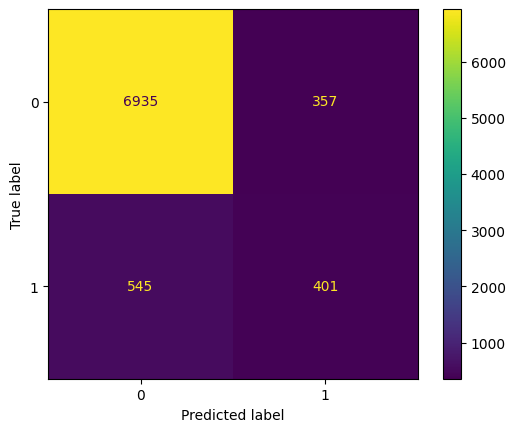

In [32]:
# Evaluate the best model on the test data
y_pred_aml_all = aml.leader.predict(val_h2o)  # Returns 3 columns.
# First column = binary prediction
# Second column = probability y = 0
# Third column = probability y = 1

y_pred_aml = y_pred_aml_all[:,0].as_data_frame(use_pandas=True).to_numpy().ravel().astype(int)
y_pred_prob_aml = y_pred_aml_all[:,2].as_data_frame(use_pandas=True).to_numpy().ravel()

# Cross-entropy
aml_cross_entropy = -np.mean(y_val * np.log(y_pred_prob_aml) + (1 - y_val) * np.log(1 - y_pred_prob_aml))
print(f'Cross-entropy (h2o) = {aml_cross_entropy:.4f}')

# Convert y_val to integer type
y_val = y_val.astype(int)

# Evaluate the model
aml_classification_metrics = classification_report(y_val, y_pred_aml, output_dict=True)
print(pd.DataFrame(aml_classification_metrics))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_aml)
plt.show()

Expected profit from h2o model: 34.60791454236465


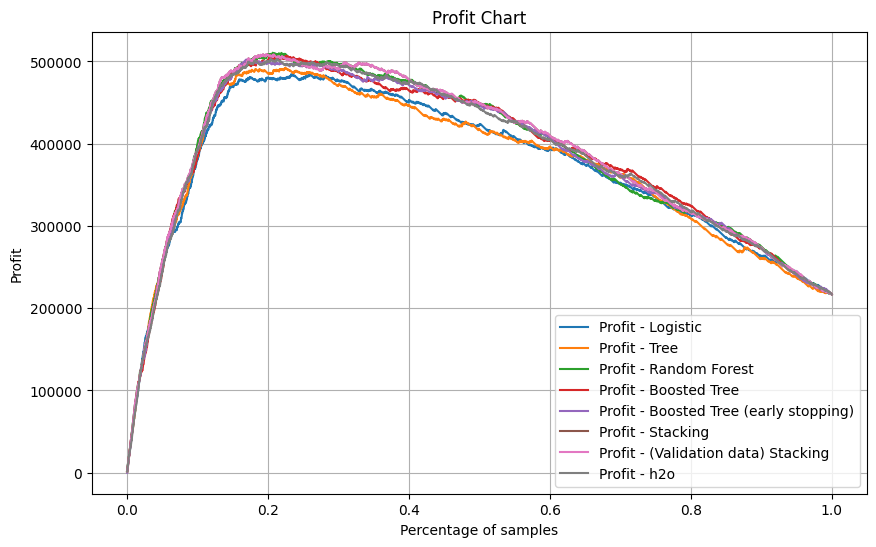

Predicted takeup probability threshold (h2o): 0.097792520045526
Maximum profit (h2o): 503000
Accuracy (h2o): 0.8293275066763778


In [33]:
# Profit
# Confusion matrix for h2o model
tn_aml, fp_aml, fn_aml, tp_aml = confusion_matrix(y_val, y_pred_aml).ravel()

# Expected profit from h2o model
Epi_aml = (tp_aml/N)*(R+C)+(fp_aml/N)*C
print(f"Expected profit from h2o model: {Epi_aml}")

# Add h2o model to profit figure
# Creating a DataFrame with the true values and predicted probabilities
dataaml = pd.DataFrame({'true': y_val, 'prob': y_pred_prob_aml})
dataaml.sort_values(by='prob', ascending=False, inplace=True)

# Calculate "profit" from contacting people ordered by their predicted probability
dataaml['profit'] = np.cumsum(dataaml['true']*(R-C)+(1-dataaml['true'])*C)
dataaml['cumulative_percentage'] = np.arange(1, len(dataaml) + 1) / len(dataaml)

# Figure
plt.figure(figsize=(10, 6))
plt.plot(datalog['cumulative_percentage'], datalog['profit'], label='Profit - Logistic')
plt.plot(datarf['cumulative_percentage'], datatr['profit'],
         label='Profit - Tree')
plt.plot(datarf['cumulative_percentage'], datarf['profit'],
         label='Profit - Random Forest')
plt.plot(datagbc['cumulative_percentage'], datagbc['profit'],
         label='Profit - Boosted Tree')
plt.plot(datagbcES['cumulative_percentage'], datagbcES['profit'],
         label='Profit - Boosted Tree (early stopping)')
plt.plot(datastack['cumulative_percentage'], datastack['profit'],
         label='Profit - Stacking')
plt.plot(dataval_stack['cumulative_percentage'], dataval_stack['profit'],
         label='Profit - (Validation data) Stacking')
plt.plot(dataaml['cumulative_percentage'], dataaml['profit'],
         label='Profit - h2o')
plt.xlabel('Percentage of samples')
plt.ylabel('Profit')
plt.title('Profit Chart')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Get predicted probability in row corresponding to maximum profit (h2o)
amlprob = dataaml.loc[dataaml['profit'].idxmax(),'prob']
print(f"Predicted takeup probability threshold (h2o): {amlprob}")
amlprof = dataaml.loc[dataaml['profit'].idxmax(),'profit']
print(f"Maximum profit (h2o): {amlprof}")

# Let's calculate accuracy using this decision threshold
amlpredictions = (y_pred_prob_aml >= amlprob).astype(int)
amlaccuracy = np.mean(amlpredictions == y_val)
print(f"Accuracy (h2o): {amlaccuracy}")
